In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_excel('capstone_airline_reviews3.xlsx')
print(df.shape)
print(df.columns.tolist())
df.head()

(131895, 17)
['airline', 'overall', 'author', 'review_date', 'customer_review', 'aircraft', 'traveller_type', 'cabin', 'route', 'date_flown', 'seat_comfort', 'cabin_service', 'food_bev', 'entertainment', 'ground_service', 'value_for_money', 'recommended']


,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,âœ… Trip Verified | London to Izmir via Istanb...,NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,âœ… Trip Verified | Istanbul to Bucharest. We ...,NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
before = len(df)
df = df.dropna(how='all').reset_index(drop=True)
print(f"Dropped {before - len(df)} fully-blank rows")

missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.9].index.tolist()
df = df.drop(columns=cols_to_drop)

cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(df.isnull().sum().sum(), "missing values remain")

Dropped 65948 fully-blank rows
0 missing values remain


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z0-9\s.,!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['customer_review'].apply(clean_text)

In [ ]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")
df.to_csv('airline_reviews_clean.csv', index=False)
print(f"Final shape: {df.shape}")

Dropped 4764 duplicate rows
Final shape: (61183, 18)


In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['review_clean'].apply(get_sentiment)
df.to_csv('airline_reviews_with_sentiment.csv', index=False)
print("Sentiment scoring done.")

Sentiment scoring done.


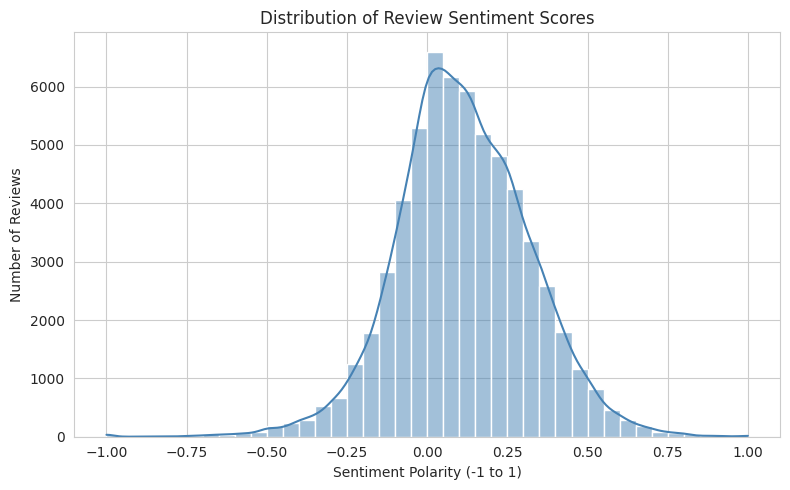

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['sentiment_score'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Review Sentiment Scores')
plt.xlabel('Sentiment Polarity (-1 to 1)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()

In [ ]:
df = pd.read_csv('airline_reviews_with_sentiment.csv')
df = df[df['recommended'].astype(str).str.strip().str.lower().isin(['yes', 'no'])].copy()
print(df['recommended'].value_counts())

recommended
no     31268
yes    28493
Name: count, dtype: int64


/tmp/ipykernel_587/792052447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['recommended'].astype(str).str.strip().str.lower(),


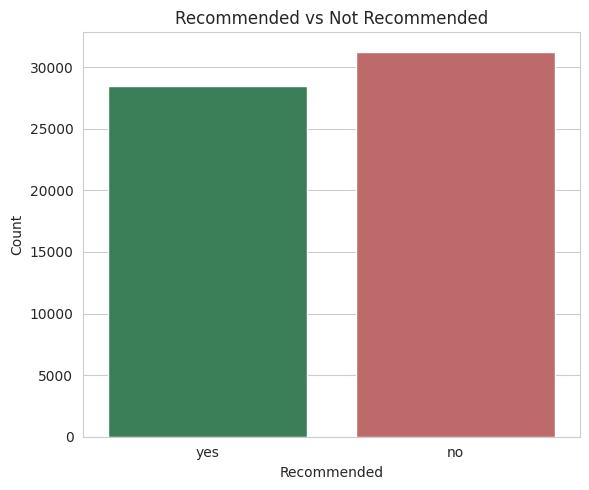

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df['recommended'].astype(str).str.strip().str.lower(),
              order=['yes', 'no'], palette=['seagreen', 'indianred'])
plt.title('Recommended vs Not Recommended')
plt.xlabel('Recommended')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('recommended_counts.png', dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = ['seat_comfort', 'cabin_service', 'food_bev', 'entertainment',
                 'ground_service', 'value_for_money', 'traveller_type', 'cabin']

X = df[feature_cols].copy()
X = pd.get_dummies(X, columns=['traveller_type', 'cabin'], drop_first=True)

y = df['recommended'].astype(str).str.strip().str.lower().map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(47808, 14) (11953, 14)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9415209570819041


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                           random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9419392621099305


In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_xgb)],
    'Precision': [precision_score(y_test, y_pred_log), precision_score(y_test, y_pred_xgb)],
    'Recall': [recall_score(y_test, y_pred_log), recall_score(y_test, y_pred_xgb)],
    'F1': [f1_score(y_test, y_pred_log), f1_score(y_test, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_log), roc_auc_score(y_test, y_proba_xgb)],
})
print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.941521   0.936605  0.941042  0.938818  0.984180
1              XGBoost  0.941939   0.940503  0.937533  0.939016  0.985549


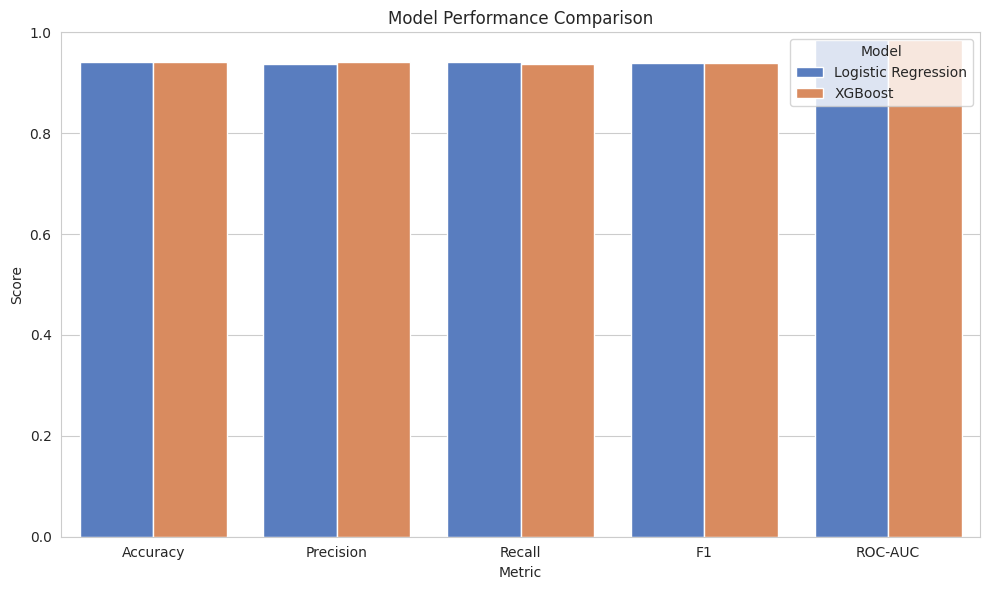

In [ ]:
metrics_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='muted')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.legend(title='Model')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

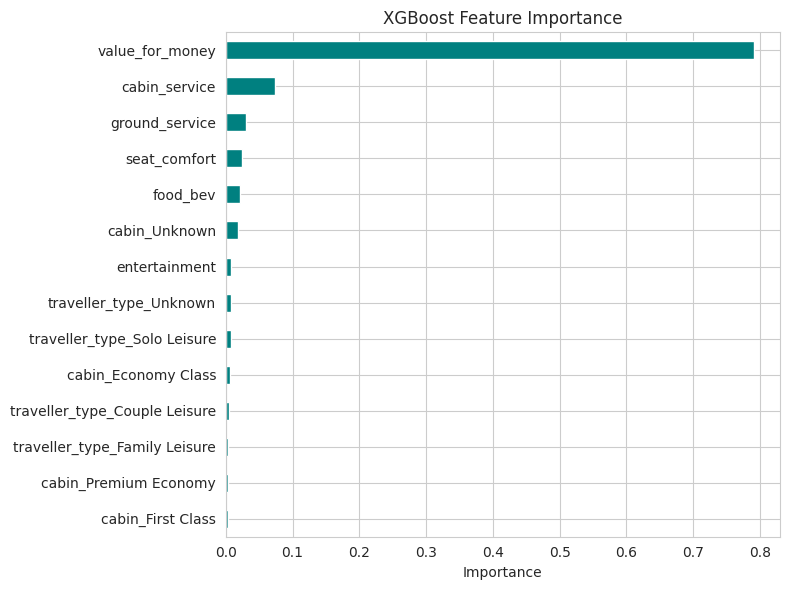

In [ ]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='teal')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
df = pd.read_csv('airline_reviews_with_sentiment.csv')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rating_cols = ['seat_comfort', 'cabin_service', 'food_bev', 'entertainment',
               'ground_service', 'value_for_money']
X_cluster = df[rating_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

scores = {}
for k_test in range(2, 8):
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10).fit(X_scaled)
    scores[k_test] = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=42)

print("Silhouette scores by k:", scores)

k = max(scores, key=scores.get)
print(f"Best k: {k}")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(df['cluster'].value_counts())

Silhouette scores by k: {2: np.float64(0.3950942199344187), 3: np.float64(0.2843698320337686), 4: np.float64(0.26390768157482397), 5: np.float64(0.22310231624880608), 6: np.float64(0.22247517082642598), 7: np.float64(0.20933884649206744)}
Best k: 2
cluster
0    31805
1    29378
Name: count, dtype: int64


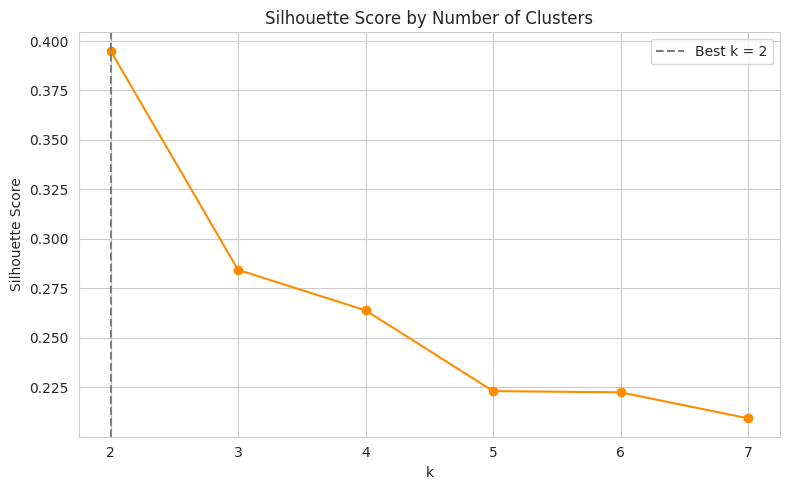

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(scores.keys()), list(scores.values()), marker='o', color='darkorange')
plt.axvline(k, color='gray', linestyle='--', label=f'Best k = {k}')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150)
plt.show()

In [ ]:
united_negative = df[
    (df['airline'].str.contains('united', case=False, na=False)) &
    (df['sentiment_score'] < 0)
]['review_clean'].sample(n=30, random_state=42).tolist()

sample_text = "\n\n".join(united_negative)

prompt = f"""Analyze these United Airlines customer complaints. Identify:
1. The top 3 recurring complaint themes
2. Which customer segment seems most affected (business/leisure/family)
3. One specific, actionable recommendation per theme

Reviews:
{sample_text}
"""

print(prompt[:500])

Analyze these United Airlines customer complaints. Identify:
1. The top 3 recurring complaint themes
2. Which customer segment seems most affected (business/leisure/family)
3. One specific, actionable recommendation per theme

Reviews:
united airlines from atlanta to bangor. i am writing this from a cot in the chicago airport. weather in chicago and my destination means my connecting flight was cancelled. i had to wait in line for five hours to be told that no, they couldnt do anything for me no


In [ ]:
!pip install -U -q google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 14.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.1 which is incompatible.


In [ ]:
from google.colab import userdata
import os
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

In [ ]:
from google import genai

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

llm_response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt,
)
llm_themes = llm_response.text

print(f"Total reviews analyzed: {len(df)}")
print(f"United reviews: {(df['airline'].str.contains('united', case=False, na=False)).sum()}")
print(f"XGBoost accuracy: {results.loc[results['Model'] == 'XGBoost', 'Accuracy'].values[0]:.4f}")
print(f"Number of customer clusters found: {k}")
print("\nLLM-identified complaint themes and recommendations:")
print(llm_themes)

Total reviews analyzed: 61183
United reviews: 2774
XGBoost accuracy: 0.9419
Number of customer clusters found: 2

LLM-identified complaint themes and recommendations:
Based on an analysis of the provided United Airlines customer complaints, here is the structured breakdown:

---

### 1. Top 3 Recurring Complaint Themes

1. **Severe Delays, Cancellations, and Operational Failures**
   * **Details:** Customers repeatedly experienced multi-hour delays (often due to recurring mechanical/maintenance issues rather than weather), missed connecting flights, extended tarmac holds, and outright cancellations without timely notification. 
   * **Examples:** Flights delayed 4–7 hours; multi-day stranding due to crew/maintenance issues; lack of backup crews or aircraft.

2. **Rude, Dismissive Staff and "Service Ping-Pong" (Refusal of Assistance)**
   * **Details:** Frontline employees (gate agents, phone support, and flight attendants) were consistently described as unhelpful, indifferent, or openl

In [ ]:
top_competitors = df['airline'].value_counts().head(4).index.tolist()
comparison = df[df['airline'].isin(top_competitors)].groupby('airline')[
    rating_cols + ['overall', 'sentiment_score']
].mean().round(2)

print(comparison)
comparison.to_csv('competitor_comparison.csv')

                   seat_comfort  cabin_service  food_bev  entertainment  \
airline                                                                   
American Airlines          2.26           2.40      2.32           2.37   
British Airways            2.91           3.26      2.75           2.72   
Spirit Airlines            1.78           2.14      2.13           2.17   
United Airlines            2.25           2.45      2.25           2.38   

                   ground_service  value_for_money  overall  sentiment_score  
airline                                                                       
American Airlines            2.07             1.99     2.89             0.03  
British Airways              2.92             2.79     4.92             0.10  
Spirit Airlines              2.08             1.87     2.65             0.01  
United Airlines              2.28             2.06     3.03             0.02  


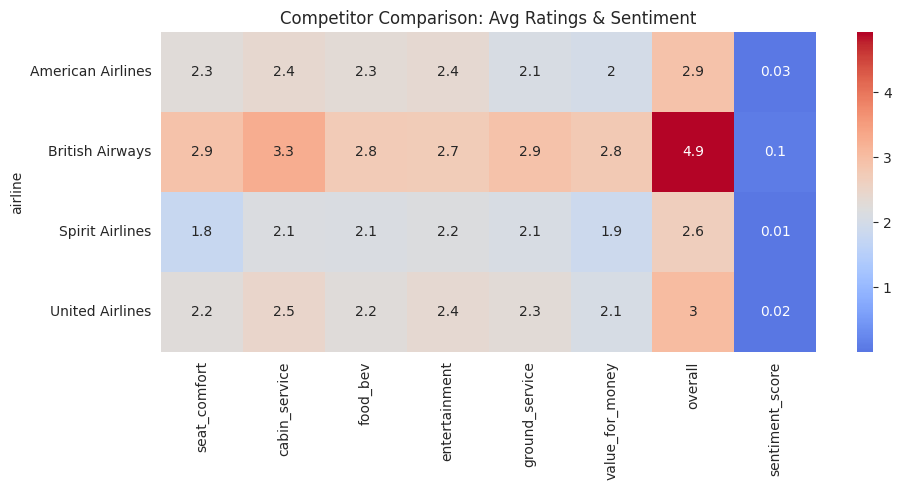

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(comparison, annot=True, cmap='coolwarm', center=comparison.values.mean())
plt.title('Competitor Comparison: Avg Ratings & Sentiment')
plt.tight_layout()
plt.savefig('competitor_comparison.png', dpi=150)
plt.show()